In [85]:
import numpy as np
import pandas as pd
import warnings
from data.loader import OracleDataLoader
from utils.helpers import get_trade_days

warnings.filterwarnings('ignore')
pd.options.display.float_format='{:.4%}'.format

In [86]:
start='2021-01-04'
end='2022-12-30'


In [87]:
def count_trading_days(start_date, end_date):
    """
    计算指定日期范围内的交易日数量
    
    参数:
        start_date (str): 开始日期，格式 'YYYY-MM-DD'
        end_date (str): 结束日期，格式 'YYYY-MM-DD'
        
    返回:
        int: 交易日数量
    """
    # 获取交易日数据
    trade_days_df = get_trade_days()
    
    # 确保TRADE_DAYS列是日期类型
    trade_days_df['TRADE_DAYS'] = pd.to_datetime(trade_days_df['TRADE_DAYS'])
    
    # 筛选指定日期范围内的交易日
    mask = (trade_days_df['TRADE_DAYS'] >= start_date) & (trade_days_df['TRADE_DAYS'] <= end_date)
    filtered_days = trade_days_df.loc[mask]
    
    # 返回交易日数量
    return len(filtered_days)

In [88]:
trading_days_count = count_trading_days(start, end)
print(f"从 {start} 到 {end} 之间的交易日数量为: {trading_days_count}")

从 2021-01-04 到 2022-12-30 之间的交易日数量为: 485


In [89]:
loader = OracleDataLoader()
df = loader.load_data('stock_detail', start_date=start, end_date=end)

In [90]:
data=df[['TRADEDATE','STOCKCODE','CLOSE']]

In [91]:
stock_counts=data.groupby('STOCKCODE')['TRADEDATE'].count()
valid_stocks=stock_counts[stock_counts==trading_days_count].index.tolist()

In [92]:
len(valid_stocks)

4292

In [93]:
data1=data[data['STOCKCODE'].isin(valid_stocks)]

### 使用score

In [94]:
stock_predict_data = pd.read_csv("input/stockpredict.csv", parse_dates=['datetime'])
stock_predict_data.columns = ['date', 'code', 'score']
stock_predict_data['date']=stock_predict_data['date'].dt.strftime('%Y%m%d')
data2=pd.merge(data1,stock_predict_data,left_on=['TRADEDATE','STOCKCODE'],right_on=['date','code'],how='left')


### 不使用score

In [95]:
data2=data1

In [96]:
print(data2.shape)
data3=data2.dropna()
print(data3.shape)

(2081620, 3)
(2081620, 3)


In [97]:
import random
stock_list=list(data3['STOCKCODE'].unique())
#从列表中随机选择25个不重复的股票
selected_stocks=random.sample(stock_list,25)
selected_stocks

['000737.SZ',
 '300603.SZ',
 '002459.SZ',
 '002937.SZ',
 '300917.SZ',
 '000983.SZ',
 '836957.BJ',
 '300077.SZ',
 '603045.SH',
 '600136.SH',
 '002968.SZ',
 '300406.SZ',
 '836419.BJ',
 '000938.SZ',
 '300440.SZ',
 '300530.SZ',
 '002919.SZ',
 '600216.SH',
 '600012.SH',
 '002821.SZ',
 '002659.SZ',
 '002716.SZ',
 '300375.SZ',
 '605177.SH',
 '600158.SH']

In [98]:
data3=data3[['TRADEDATE','STOCKCODE','CLOSE','score']]
data3.head()

KeyError: "['score'] not in index"

In [139]:
selected_stocks=['603801.SH','601186.SH','600089.SH','601858.SH','002284.SZ','300221.SZ','600462.SH','002943.SZ','002566.SZ',
                          '002578.SZ','600873.SH','300720.SZ','300658.SZ','600530.SH','300654.SZ','600326.SH','300257.SZ','600225.SH','300312.SZ']

In [140]:
# stock_remove=['001336.SZ','301035.SZ',"301058.SZ","688011.SH","688575.SH","873152.BJ"]
# selected_stocks=list(set(selected_stocks)-set(stock_remove))

data4=data3[data3['STOCKCODE'].isin(selected_stocks)]

In [141]:
data4

,TRADEDATE,STOCKCODE,CLOSE
117,20210104,300257.SZ,8967.0000%
239,20210104,600089.SH,41483.0000%
281,20210104,300720.SZ,3882.0000%
306,20210104,002284.SZ,4417.0000%
608,20210104,600326.SH,5752.0000%
...,...,...,...
2320407,20221230,002284.SZ,4651.0000%
2320608,20221230,002578.SZ,2252.0000%
2321020,20221230,600530.SH,2431.0000%
2321770,20221230,600326.SH,3725.0000%


In [142]:
df_pivot=data4.pivot(index='TRADEDATE',columns='STOCKCODE',values="CLOSE")
df_pivot

STOCKCODE,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
TRADEDATE,,,,,,,,,,,,,,,,,,
20210104,4417.0000%,2049.0000%,1855.0000%,1816.0000%,4060.0000%,8967.0000%,1854.0000%,4551.0000%,3882.0000%,41483.0000%,362.0000%,5752.0000%,999.0000%,1772.0000%,3284.0000%,982.0000%,992.0000%,4811.0000%
20210105,4274.0000%,1999.0000%,1834.0000%,1805.0000%,3803.0000%,8820.0000%,1920.0000%,4471.0000%,3703.0000%,40630.0000%,370.0000%,5833.0000%,971.0000%,1733.0000%,3446.0000%,978.0000%,974.0000%,4857.0000%
20210106,4041.0000%,1956.0000%,1793.0000%,1726.0000%,3866.0000%,8538.0000%,1935.0000%,4809.0000%,3554.0000%,39854.0000%,351.0000%,5945.0000%,971.0000%,1708.0000%,3411.0000%,1023.0000%,961.0000%,4784.0000%
20210107,3847.0000%,1895.0000%,1777.0000%,1623.0000%,3988.0000%,8236.0000%,1783.0000%,4655.0000%,3573.0000%,40901.0000%,333.0000%,5712.0000%,967.0000%,1676.0000%,3418.0000%,999.0000%,933.0000%,4524.0000%
20210108,3802.0000%,1925.0000%,1700.0000%,1594.0000%,3803.0000%,8743.0000%,1759.0000%,4716.0000%,3415.0000%,39738.0000%,330.0000%,5704.0000%,967.0000%,1669.0000%,3432.0000%,1004.0000%,953.0000%,4612.0000%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20221226,4809.0000%,2592.0000%,2184.0000%,5580.0000%,2055.0000%,9500.0000%,1919.0000%,2319.0000%,3571.0000%,76944.0000%,1325.0000%,3725.0000%,926.0000%,2475.0000%,7913.0000%,1035.0000%,1263.0000%,6041.0000%
20221227,4802.0000%,2499.0000%,2236.0000%,5914.0000%,2076.0000%,9648.0000%,1915.0000%,2276.0000%,3743.0000%,78237.0000%,1347.0000%,3783.0000%,913.0000%,2482.0000%,7974.0000%,1039.0000%,1264.0000%,6249.0000%
20221228,4664.0000%,2458.0000%,2226.0000%,5896.0000%,2034.0000%,9616.0000%,1909.0000%,2201.0000%,3743.0000%,77792.0000%,1411.0000%,3766.0000%,899.0000%,2443.0000%,7898.0000%,1030.0000%,1206.0000%,5979.0000%


In [114]:
df_pivot.index=pd.to_datetime(df_pivot.index)
df_pivot.sort_index(inplace=True)

In [115]:
df_pivot

STOCKCODE,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
TRADEDATE,,,,,,,,,,,,,,,,,,
2021-01-04,4417.0000%,2049.0000%,1855.0000%,1816.0000%,4060.0000%,8967.0000%,1854.0000%,4551.0000%,3882.0000%,41483.0000%,362.0000%,5752.0000%,999.0000%,1772.0000%,3284.0000%,982.0000%,992.0000%,4811.0000%
2021-01-05,4274.0000%,1999.0000%,1834.0000%,1805.0000%,3803.0000%,8820.0000%,1920.0000%,4471.0000%,3703.0000%,40630.0000%,370.0000%,5833.0000%,971.0000%,1733.0000%,3446.0000%,978.0000%,974.0000%,4857.0000%
2021-01-06,4041.0000%,1956.0000%,1793.0000%,1726.0000%,3866.0000%,8538.0000%,1935.0000%,4809.0000%,3554.0000%,39854.0000%,351.0000%,5945.0000%,971.0000%,1708.0000%,3411.0000%,1023.0000%,961.0000%,4784.0000%
2021-01-07,3847.0000%,1895.0000%,1777.0000%,1623.0000%,3988.0000%,8236.0000%,1783.0000%,4655.0000%,3573.0000%,40901.0000%,333.0000%,5712.0000%,967.0000%,1676.0000%,3418.0000%,999.0000%,933.0000%,4524.0000%
2021-01-08,3802.0000%,1925.0000%,1700.0000%,1594.0000%,3803.0000%,8743.0000%,1759.0000%,4716.0000%,3415.0000%,39738.0000%,330.0000%,5704.0000%,967.0000%,1669.0000%,3432.0000%,1004.0000%,953.0000%,4612.0000%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-26,4809.0000%,2592.0000%,2184.0000%,5580.0000%,2055.0000%,9500.0000%,1919.0000%,2319.0000%,3571.0000%,76944.0000%,1325.0000%,3725.0000%,926.0000%,2475.0000%,7913.0000%,1035.0000%,1263.0000%,6041.0000%
2022-12-27,4802.0000%,2499.0000%,2236.0000%,5914.0000%,2076.0000%,9648.0000%,1915.0000%,2276.0000%,3743.0000%,78237.0000%,1347.0000%,3783.0000%,913.0000%,2482.0000%,7974.0000%,1039.0000%,1264.0000%,6249.0000%
2022-12-28,4664.0000%,2458.0000%,2226.0000%,5896.0000%,2034.0000%,9616.0000%,1909.0000%,2201.0000%,3743.0000%,77792.0000%,1411.0000%,3766.0000%,899.0000%,2443.0000%,7898.0000%,1030.0000%,1206.0000%,5979.0000%


In [116]:
Y=df_pivot.pct_change().dropna()
display(Y)

STOCKCODE,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
TRADEDATE,,,,,,,,,,,,,,,,,,
2021-01-05,-3.2375%,-2.4402%,-1.1321%,-0.6057%,-6.3300%,-1.6393%,3.5599%,-1.7579%,-4.6110%,-2.0563%,2.2099%,1.4082%,-2.8028%,-2.2009%,4.9330%,-0.4073%,-1.8145%,0.9561%
2021-01-06,-5.4516%,-2.1511%,-2.2356%,-4.3767%,1.6566%,-3.1973%,0.7813%,7.5598%,-4.0238%,-1.9099%,-5.1351%,1.9201%,0.0000%,-1.4426%,-1.0157%,4.6012%,-1.3347%,-1.5030%
2021-01-07,-4.8008%,-3.1186%,-0.8924%,-5.9676%,3.1557%,-3.5371%,-7.8553%,-3.2023%,0.5346%,2.6271%,-5.1282%,-3.9193%,-0.4119%,-1.8735%,0.2052%,-2.3460%,-2.9136%,-5.4348%
2021-01-08,-1.1697%,1.5831%,-4.3331%,-1.7868%,-4.6389%,6.1559%,-1.3460%,1.3104%,-4.4221%,-2.8435%,-0.9009%,-0.1401%,0.0000%,-0.4177%,0.4096%,0.5005%,2.1436%,1.9452%
2021-01-11,2.2094%,-3.8442%,-6.0588%,-0.8783%,1.2096%,-2.2761%,-4.4912%,2.1628%,-6.3250%,-4.3887%,-4.8485%,-2.9628%,-3.3092%,-1.1384%,0.8159%,-2.1912%,1.5740%,0.3903%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-26,3.2639%,0.8560%,0.7380%,10.0158%,2.0864%,1.6478%,-0.6214%,-1.0243%,3.0592%,2.4213%,2.8727%,-0.8781%,0.4338%,-3.0172%,-1.4325%,-0.1929%,1.2831%,-2.3440%
2022-12-27,-0.1456%,-3.5880%,2.3810%,5.9857%,1.0219%,1.5579%,-0.2084%,-1.8542%,4.8166%,1.6804%,1.6604%,1.5570%,-1.4039%,0.2828%,0.7709%,0.3865%,0.0792%,3.4431%
2022-12-28,-2.8738%,-1.6407%,-0.4472%,-0.3044%,-2.0231%,-0.3317%,-0.3133%,-3.2953%,0.0000%,-0.5688%,4.7513%,-0.4494%,-1.5334%,-1.5713%,-0.9531%,-0.8662%,-4.5886%,-4.3207%


In [74]:
# 2. 提取最新的 score（确保与 Y.columns 顺序一致）
#如果每个股票在每个交易日都有 score，可以直接用最后一天的 score
latest_scores = data4[data4['TRADEDATE'] == data4['TRADEDATE'].max()] \
    .set_index('STOCKCODE')['score']
# 确保 score 顺序与 Y 的列顺序一致
scores_aligned = latest_scores[Y.columns]

In [75]:
scores_aligned

STOCKCODE
000413.SZ    -3.1082%
002214.SZ    -6.5264%
002403.SZ    -2.8150%
002554.SZ     1.2192%
300051.SZ   -20.5578%
300121.SZ    -3.5841%
300386.SZ    -2.7141%
300457.SZ     5.2529%
300505.SZ    -6.5060%
300566.SZ    -1.7758%
300580.SZ    -0.5748%
300796.SZ    -1.4297%
600159.SH    -7.9356%
600309.SH     2.8206%
600419.SH    -7.0511%
600600.SH     5.8737%
600605.SH     9.5530%
600749.SH    -6.8782%
600875.SH     0.4499%
600962.SH    -5.8741%
601005.SH     1.2835%
601216.SH    -5.4367%
601857.SH     3.8979%
603040.SH    -3.3865%
603298.SH    -1.0303%
Name: score, dtype: float64

## 使用历史估计的均值风险组合优化

In [117]:
import riskfolio as rp

In [118]:
port=rp.Portfolio(returns=Y)

method_mu='hist' #历史平均收益率作为预期收益率
method_cov='hist' #历史协方差矩阵作为风险估计
port.assets_stats(method_mu='hist',method_cov='hist')

# 设置自定义预期收益率
# port.mu = np.array(scores_aligned)

model='Classic' #经典均值-方差模型
rm='MV'  #风险度量：方差
obj='Sharpe'  
hist=True  #使用历史数据计算风险
rf=0  #无风险利率
l=0  #风险厌恶系数，因为obj为Sharpe，未使用

w=port.optimization(model=model,rm=rm,obj=obj,rf=rf,l=l,hist=hist)
display(w.T)

,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
weights,0.0000%,0.0000%,0.0000%,10.9016%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,9.1971%,45.8218%,0.0000%,0.0000%,2.8204%,26.2666%,0.0000%,2.6913%,2.3012%


In [119]:
port.mu

,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
0,0.0673%,0.0844%,0.0903%,0.3360%,-0.0980%,0.0524%,0.0486%,-0.0985%,0.0507%,0.1845%,0.3632%,-0.0698%,0.0112%,0.1052%,0.2100%,0.0236%,0.0696%,0.0962%


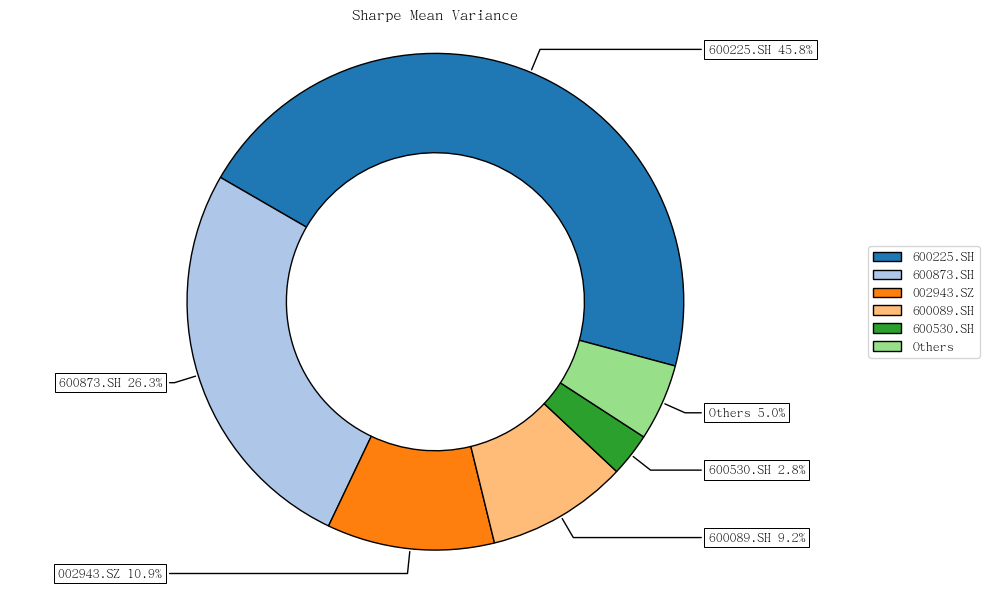

In [120]:
ax=rp.plot_pie(w=w,title='Sharpe Mean Variance',others=0.05,nrow=25,cmap='tab20',height=6,width=10,ax=None)

In [121]:
#计算有效前沿，表示给定风险水平下能获得的最高预期收益（给定收益下的最低风险）的所有组合集合
points=50
frontier=port.efficient_frontier(model=model,rm=rm,points=points,rf=rf,hist=hist)
display(frontier.T.head())

,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
0,1.4453%,4.0190%,0.6285%,0.1523%,0.1770%,6.6089%,0.6875%,3.0074%,3.8922%,4.2061%,10.7734%,2.0614%,15.3785%,3.2355%,4.2070%,31.6831%,5.1896%,2.6473%
1,0.4250%,4.4737%,0.0000%,2.5871%,0.0000%,4.8017%,0.0000%,0.0000%,3.0193%,5.6662%,17.0940%,0.0000%,11.9333%,4.4593%,9.1940%,27.2038%,6.1409%,3.0018%
2,0.0000%,4.3906%,0.0000%,3.5318%,0.0000%,3.8178%,0.0000%,0.0000%,2.3711%,6.3569%,20.1086%,0.0000%,9.7504%,4.6291%,11.2138%,24.3819%,6.3208%,3.1272%
3,0.0000%,4.2971%,0.0000%,4.2266%,0.0000%,3.0242%,0.0000%,0.0000%,1.8259%,6.8716%,22.4421%,0.0000%,8.0067%,4.7063%,12.7307%,22.2128%,6.4318%,3.2242%
4,0.0000%,4.2172%,0.0000%,4.8182%,0.0000%,2.3478%,0.0000%,0.0000%,1.3611%,7.3077%,24.4298%,0.0000%,6.5216%,4.7721%,14.0225%,20.3678%,6.5271%,3.3070%


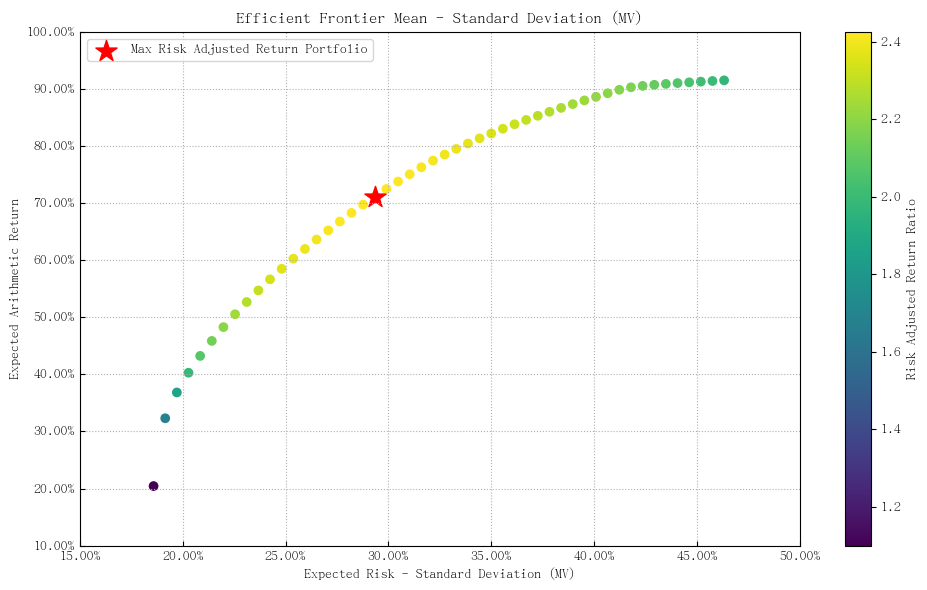

In [122]:
label='Max Risk Adjusted Return Portfolio'
mu=port.mu         #资产的预期收益率向量
cov=port.cov       #资产的协方差矩阵
returns=port.returns  #资产的历史收益率数据

ax=rp.plot_frontier(w_frontier=frontier,mu=mu,cov=cov,returns=returns,rm=rm,rf=rf,alpha=0.05,cmap="viridis",w=w,label=label,marker='*',s=16,c='r',height=6,width=10,ax=None)

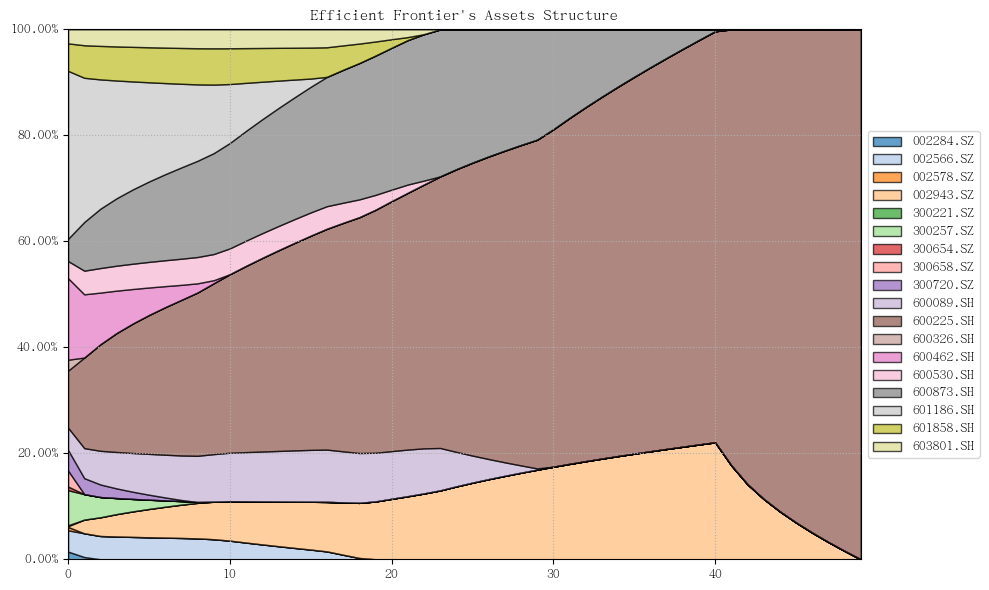

In [126]:
ax=rp.plot_frontier_area(w_frontier=frontier,cmap='tab20',height=6,width=10,ax=None)

In [127]:
rm='CVaR'

w=port.optimization(model=model,rm=rm,obj=obj,rf=rf,l=l,hist=hist)

display(w.T)

,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
weights,0.0000%,0.0000%,0.0000%,10.2330%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,5.2868%,55.3263%,0.0000%,0.0000%,0.0000%,29.1539%,0.0000%,0.0000%,0.0000%


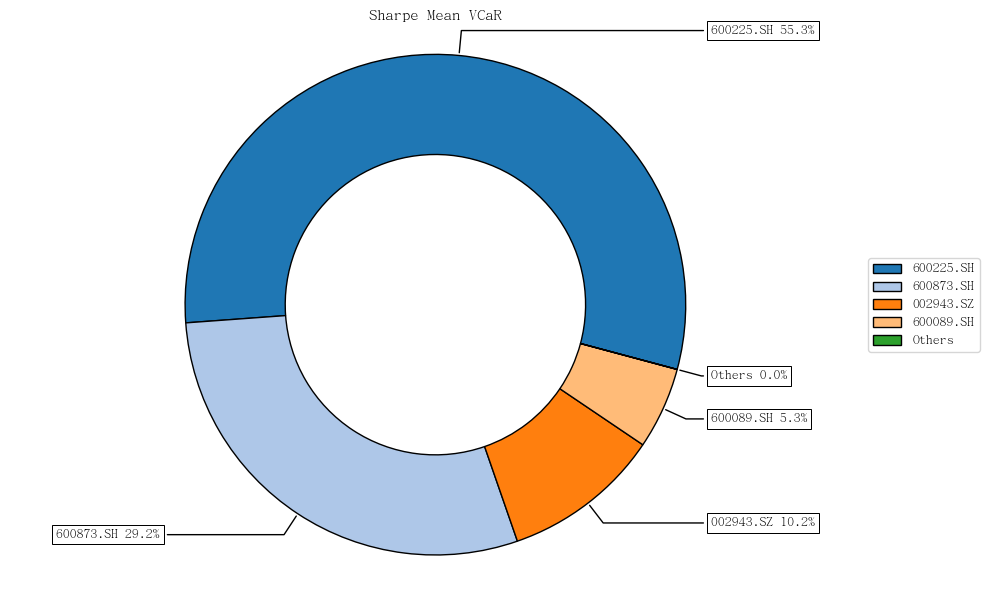

In [128]:
ax=rp.plot_pie(w=w,title='Sharpe Mean VCaR',others=0.05,nrow=25,cmap='tab20',height=6,width=10,ax=None)

In [129]:
points=50
frontier=port.efficient_frontier(model=model,rm=rm,points=points,rf=rf,hist=hist)
display(frontier.T.head())

,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
0,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,2.6554%,0.0000%,0.0000%,6.2962%,1.8809%,18.9910%,0.0000%,5.4946%,0.0000%,0.0000%,44.2552%,17.5979%,2.8289%
1,0.0000%,0.0000%,0.0000%,2.8616%,0.0000%,6.8843%,0.0000%,0.0000%,5.3166%,1.9882%,20.7643%,0.0000%,2.3034%,0.0000%,9.8784%,29.1342%,17.1302%,3.7389%
2,0.0000%,0.0000%,0.0000%,2.7039%,0.0000%,7.0167%,0.0000%,0.0000%,5.2373%,6.9477%,22.7058%,0.0000%,1.3775%,0.0000%,11.5935%,21.0410%,18.4334%,2.9431%
3,0.0000%,0.8725%,0.0000%,3.7715%,0.0000%,5.9849%,0.0000%,0.0000%,4.7952%,5.6788%,24.2892%,0.0000%,0.0000%,0.0000%,14.3626%,22.4522%,15.3843%,2.4088%
4,0.0000%,0.3295%,0.0000%,2.8263%,0.0000%,4.8627%,0.0000%,0.0000%,3.9767%,7.1763%,27.2486%,0.0000%,0.0000%,0.0000%,15.0188%,20.5796%,16.1483%,1.8333%


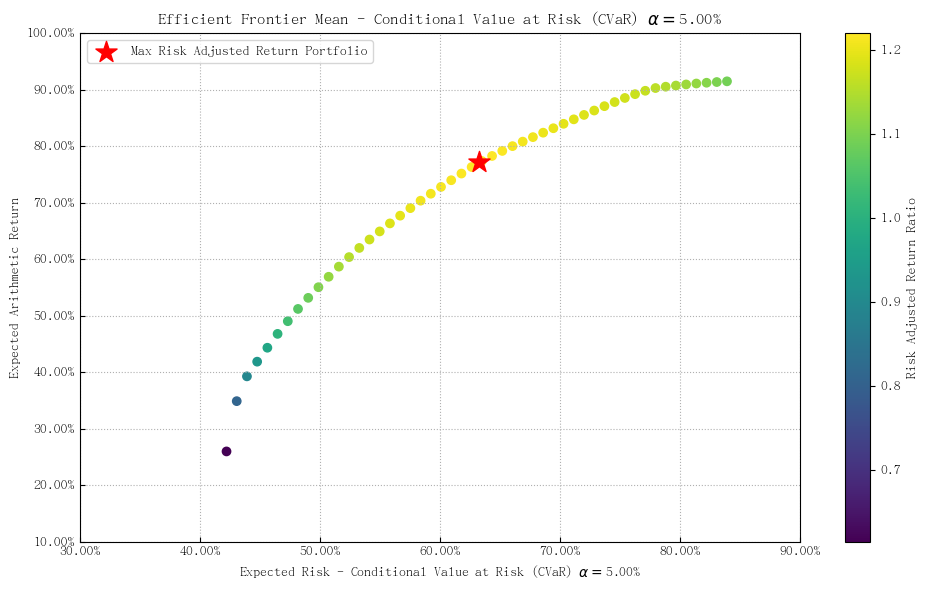

In [130]:
label='Max Risk Adjusted Return Portfolio'

ax=rp.plot_frontier(w_frontier=frontier,mu=mu,cov=cov,returns=returns,rm=rm,rf=rf,alpha=0.05,cmap='viridis',w=w,label=label,marker='*',s=16,c='r',height=6,width=10,ax=None)

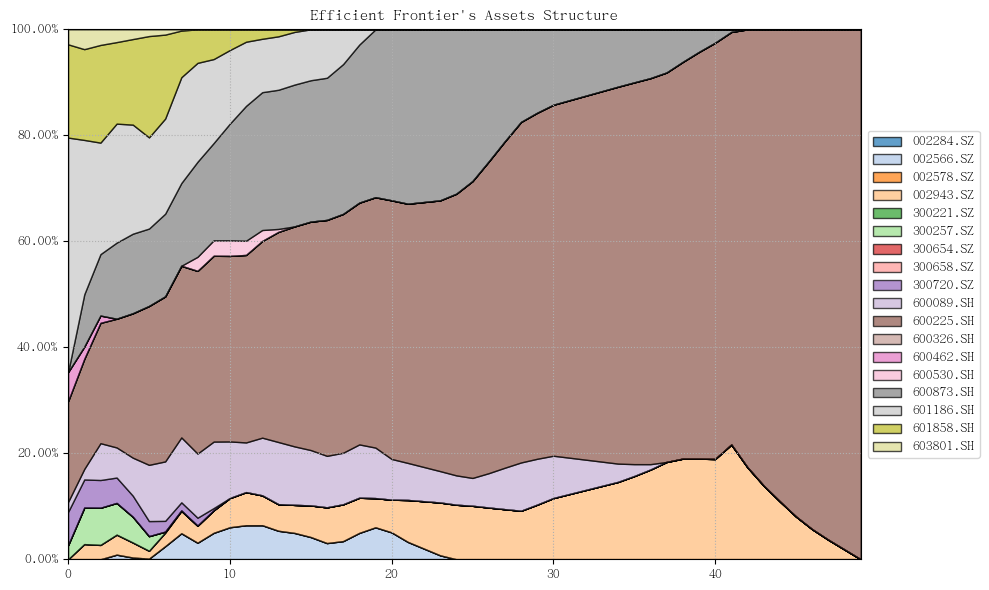

In [131]:
ax=rp.plot_frontier_area(w_frontier=frontier,cmap='tab20',height=6,width=10,ax=None)

### 多种风险度量

In [132]:
rms=['MV','MAD','MSV','FLPM','SLPM','CVaR','EVaR','WR','MDD','ADD','CDaR','UCI','EDaR']

w_s=pd.DataFrame([])

for i in rms:
    w=port.optimization(model=model,rm=i,obj=obj,rf=rf,l=l,hist=hist)
    w_s=pd.concat([w_s,w],axis=1)
    
w_s.columns=rms

In [133]:
display(w_s)

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
002284.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
002566.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0662%,4.2702%,3.0774%,5.1066%,0.0938%
002578.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,2.5679%,0.0000%,0.0000%,0.0000%
002943.SZ,10.9016%,10.4165%,9.9137%,10.0195%,9.7200%,10.2330%,7.4867%,8.8261%,0.0000%,1.4338%,4.1233%,2.1040%,3.0931%
300221.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
300257.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,7.6153%,14.5354%,14.7999%,13.7958%,10.4685%
300654.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,1.5628%,0.0000%,0.0000%,0.0000%
300658.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
300720.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
600089.SH,9.1971%,11.6700%,11.5924%,12.1813%,11.5135%,5.2868%,19.1549%,25.3698%,13.1936%,0.0000%,4.9183%,1.4748%,8.5908%


<Axes: >

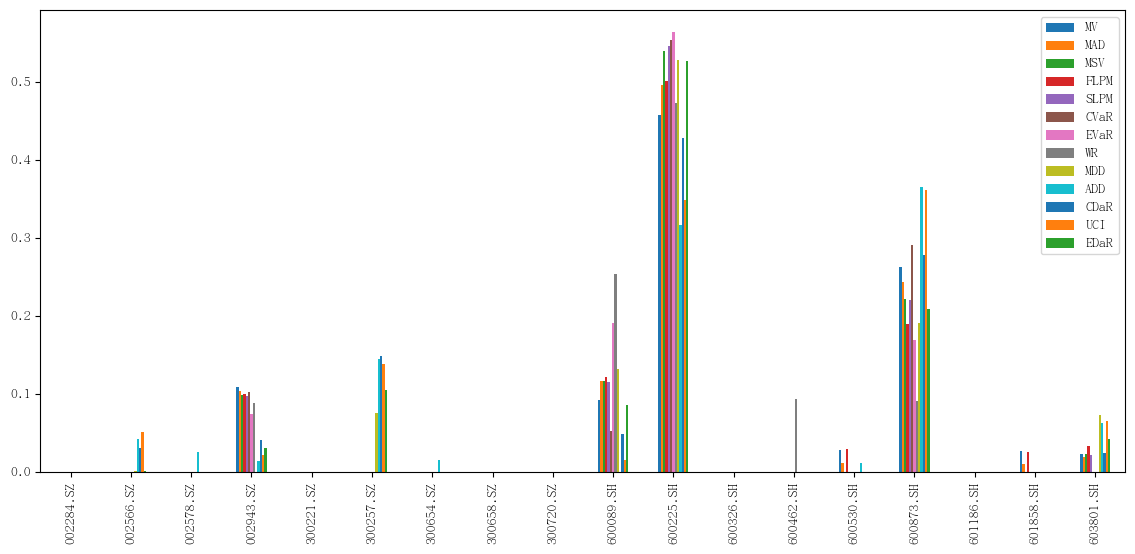

In [134]:
import matplotlib.pyplot as plt

fig=plt.gcf()
fig.set_figwidth(14)
fig.set_figheight(6)
ax=fig.subplots(nrows=1,ncols=1)

w_s.plot.bar(ax=ax)

In [135]:
w_s

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
002284.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
002566.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0662%,4.2702%,3.0774%,5.1066%,0.0938%
002578.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,2.5679%,0.0000%,0.0000%,0.0000%
002943.SZ,10.9016%,10.4165%,9.9137%,10.0195%,9.7200%,10.2330%,7.4867%,8.8261%,0.0000%,1.4338%,4.1233%,2.1040%,3.0931%
300221.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
300257.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,7.6153%,14.5354%,14.7999%,13.7958%,10.4685%
300654.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,1.5628%,0.0000%,0.0000%,0.0000%
300658.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
300720.SZ,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
600089.SH,9.1971%,11.6700%,11.5924%,12.1813%,11.5135%,5.2868%,19.1549%,25.3698%,13.1936%,0.0000%,4.9183%,1.4748%,8.5908%


### 资产和资产类别的限制

In [233]:
asset_classes={'Assets': ['603801.SH','601186.SH','600089.SH','601858.SH','300221.SZ','600462.SH','002943.SZ','002566.SZ',
                          '002578.SZ','600873.SH','300720.SZ','300658.SZ','600530.SH','300654.SZ','600326.SH','300257.SZ','600225.SH','300312.SZ'],
               'Industry':['轻工制造','建筑装饰','电气设备','传媒','化工','通信','机械设备','医药生物',
                           '有色金属','农林牧渔','机械设备','纺织服装','医药生物','传媒','建筑装饰','机械设备','房地产','通信']
}
asset_classes=pd.DataFrame(asset_classes)
asset_classes=asset_classes.sort_values(by=['Assets'])

constrains={
    'Disabled':[False,False,False,False,False,False],
    'Type':['All Assets','Classes','Classes','Classes','Classes','Assets'],
    'Set':['','Industry','Industry','Industry','Industry',''],
    'Position':['','医药生物','农林牧渔','通信','房地产','600873.SH'],
    'Sign':['<=','<=','<=','<=','<=','<='],
    'Weight':[0.1,0.1,0.1,0.1,0.1,0.08],
    'Type Relative':['','','','','',''],
    'Relative Set':['','','','','',''],
    'Relative':['','','','','',''],
    'Factor':['','','','','','']
}

constrains=pd.DataFrame(constrains)
display(constrains)

,Disabled,Type,Set,Position,Sign,Weight,Type Relative,Relative Set,Relative,Factor
0,False,All Assets,,,<=,10.0000%,,,,
1,False,Classes,Industry,医药生物,<=,10.0000%,,,,
2,False,Classes,Industry,农林牧渔,<=,10.0000%,,,,
3,False,Classes,Industry,通信,<=,10.0000%,,,,
4,False,Classes,Industry,房地产,<=,10.0000%,,,,
5,False,Assets,,600873.SH,<=,8.0000%,,,,


In [234]:
A,B=rp.assets_constraints(constrains,asset_classes)

In [235]:
port.ainequality=A
port.binequality=B

model='Classic'  #经典均值-方差模型
rm='MV'  #方差
obj='Sharpe'
rf=0  #无风险利率

w=port.optimization(model=model,rm=rm,obj=obj,rf=rf,l=l,hist=hist)

display(w.T)

,002284.SZ,002566.SZ,002578.SZ,002943.SZ,300221.SZ,300257.SZ,300654.SZ,300658.SZ,300720.SZ,600089.SH,600225.SH,600326.SH,600462.SH,600530.SH,600873.SH,601186.SH,601858.SH,603801.SH
weights,0.0000%,9.5813%,4.1945%,10.0000%,0.0000%,3.8538%,0.0000%,0.0000%,0.9263%,10.0000%,10.0000%,0.0000%,4.4669%,10.0000%,8.0000%,10.0000%,10.0000%,8.9771%


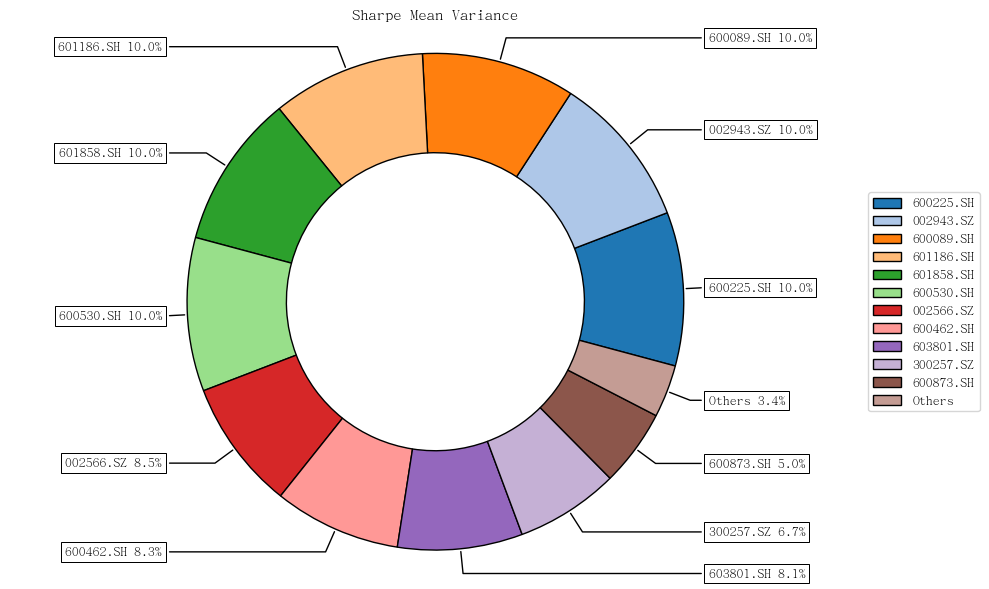

In [223]:
ax=rp.plot_pie(w=w,title='Sharpe Mean Variance',others=0.05,nrow=25,cmap='tab20',height=6,width=10,ax=None)

In [224]:
w_classes=pd.concat([asset_classes.set_index('Assets'),w],axis=1)

display(w_classes)

,Industry,weights
002566.SZ,医药生物,8.4533%
002578.SZ,有色金属,3.3436%
002943.SZ,机械设备,10.0000%
300221.SZ,化工,0.0000%
300257.SZ,机械设备,6.7390%
300312.SZ,通信,NaN
300654.SZ,传媒,0.0000%
300658.SZ,纺织服装,0.0000%
300720.SZ,机械设备,0.0714%
600089.SH,电气设备,10.0000%


In [225]:
w_classes=w_classes.groupby(['Industry']).sum()

display(w_classes)

,weights
Industry,
传媒,10.0000%
农林牧渔,5.0000%
化工,0.0000%
医药生物,18.4533%
建筑装饰,10.0000%
房地产,10.0000%
有色金属,3.3436%
机械设备,16.8104%
电气设备,10.0000%


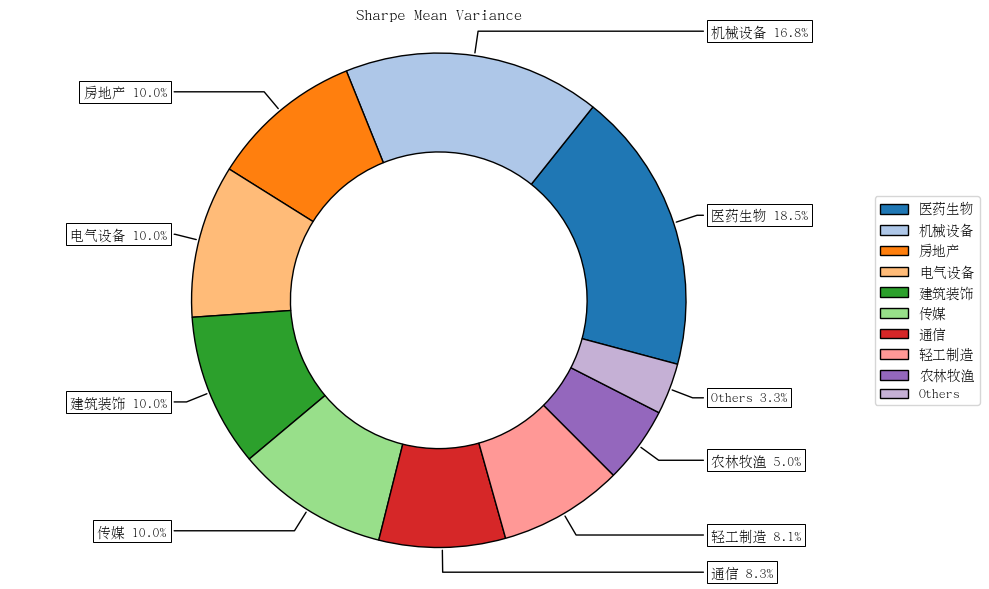

In [226]:
ax=rp.plot_pie(w=w_classes,title='Sharpe Mean Variance',others=0.05,nrow=25,cmap='tab20',height=6,width=10,ax=None)

In [198]:
import riskfolio as rp

asset_classes = {'Assets': ['FB', 'GOOGL', 'NTFX', 'BAC', 'WFC', 'TLT', 'SHV'],
                 'Class 1': ['Equity', 'Equity', 'Equity', 'Equity', 'Equity',
                             'Fixed Income', 'Fixed Income'],
                 'Class 2': ['Technology', 'Technology', 'Technology',
                             'Financial', 'Financial', 'Treasury', 'Treasury'],}

asset_classes = pd.DataFrame(asset_classes)
asset_classes = asset_classes.sort_values(by=['Assets'])

constraints = {'Disabled': [False, False, False, False, False, False, False],
               'Type': ['Classes', 'Classes', 'Assets', 'Assets', 'Classes',
                        'All Assets', 'Each asset in a class'],
               'Set': ['Class 1', 'Class 1', '', '', 'Class 2', '', 'Class 1'],
               'Position': ['Equity', 'Fixed Income', 'BAC', 'WFC', 'Financial',
                            '', 'Equity'],
               'Sign': ['<=', '<=', '<=', '<=', '>=', '>=', '>='],
               'Weight': [0.6, 0.5, 0.1, '', '', 0.02, ''],
               'Type Relative': ['', '', '', 'Assets', 'Classes', '', 'Assets'],
               'Relative Set': ['', '', '', '', 'Class 1', '', ''],
               'Relative': ['', '', '', 'FB', 'Fixed Income', '', 'TLT'],
               'Factor': ['', '', '', 1.2, 0.5, '', 0.4]}

constraints = pd.DataFrame(constraints)

In [199]:
constraints

,Disabled,Type,Set,Position,Sign,Weight,Type Relative,Relative Set,Relative,Factor
0,False,Classes,Class 1,Equity,<=,60.0000%,,,,
1,False,Classes,Class 1,Fixed Income,<=,50.0000%,,,,
2,False,Assets,,BAC,<=,10.0000%,,,,
3,False,Assets,,WFC,<=,,Assets,,FB,120.0000%
4,False,Classes,Class 2,Financial,>=,,Classes,Class 1,Fixed Income,50.0000%
5,False,All Assets,,,>=,2.0000%,,,,
6,False,Each asset in a class,Class 1,Equity,>=,,Assets,,TLT,40.0000%


In [200]:
A, B = rp.assets_constraints(constraints, asset_classes)

In [202]:
B

array([[-0.6 ],
       [-0.5 ],
       [-0.1 ],
       [ 0.  ],
       [ 0.  ],
       [ 0.02],
       [ 0.02],
       [ 0.02],
       [ 0.02],
       [ 0.02],
       [ 0.02],
       [ 0.02],
       [ 0.  ],
       [ 0.  ],
       [ 0.  ],
       [ 0.  ],
       [ 0.  ]])